# STARTUP SPENDING TO PREDICT PROFIT(Multiple Linear Regression)

# Problem Statement
 - The objective of this project is to analyze the impact of research and development expenditure, administration costs, and marketing expenditure on the profits of startup companies and develop a machine learning model to accurately predict startup profits.

# 📈 Workflow Architecture

# 📊 Data Structure

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [ ]:
df=pd.read_csv(r"50_Startups.csv")
df


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


# Data Understanding

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [5]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 50
Number of Columns: 5


In [6]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
df.describe(include=object)

,State
count,50
unique,3
top,New York
freq,17


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [10]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

# Data Quality Checks


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

# EDA

<Axes: >

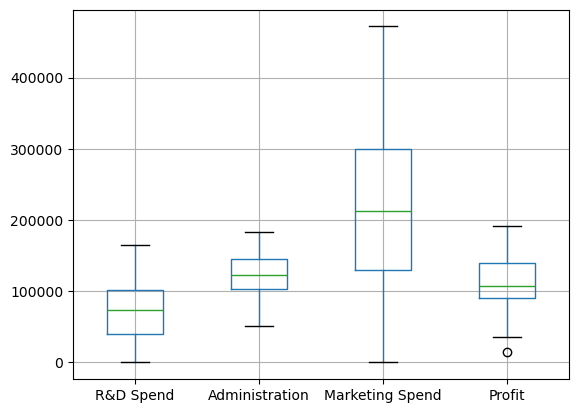

In [13]:
df.boxplot()

In [14]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

## Univariate Analysis 

In [15]:
num_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

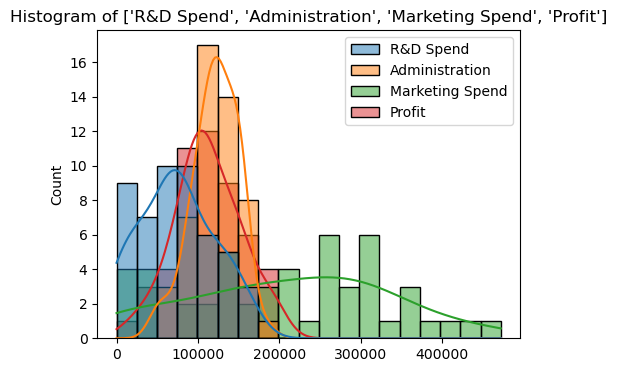

In [16]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[num_cols], kde=True)
plt.title(f'Histogram of {num_cols}')
plt.show()

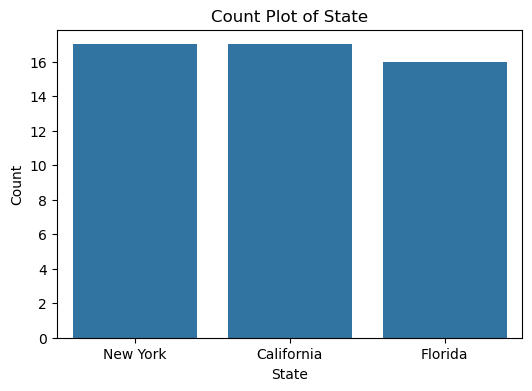

In [17]:
# Univariate Analysis for Categorical Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='State', data=df)
plt.title('Count Plot of State')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()

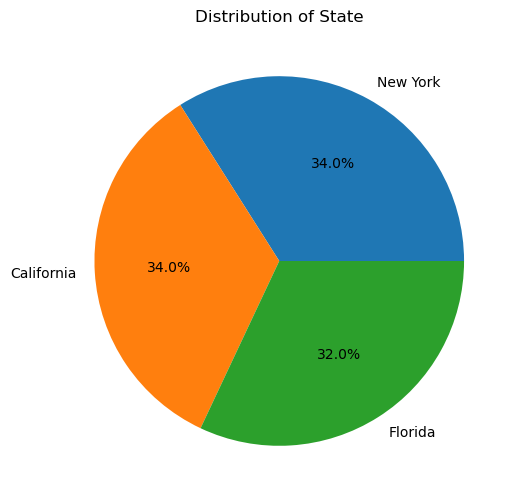

In [18]:
# Pie Chart for State
df['State'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6)
)
plt.title('Distribution of State')
plt.ylabel('')
plt.show()

# Bivariate analysis

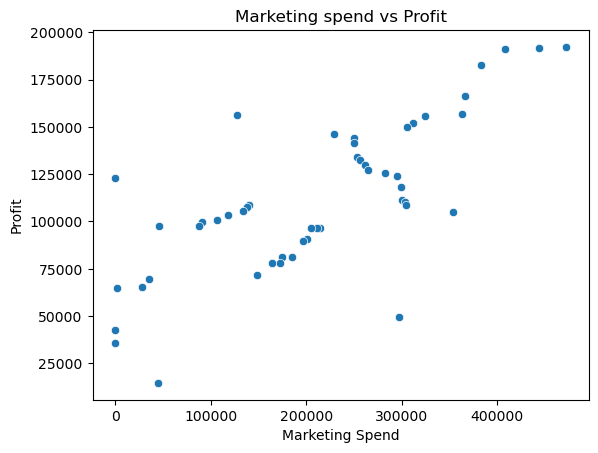

In [19]:
sns.scatterplot(x=df['Marketing Spend'],y=df['Profit'])
plt.title('Marketing spend vs Profit')
plt.show()

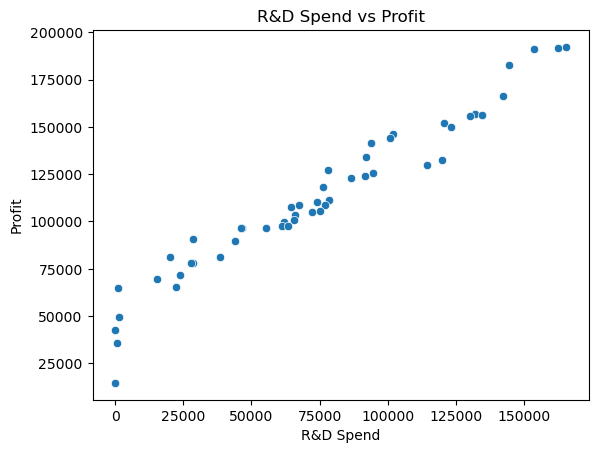

In [20]:
sns.scatterplot(data=df, x='R&D Spend', y='Profit')
plt.title('R&D Spend vs Profit')
plt.show()

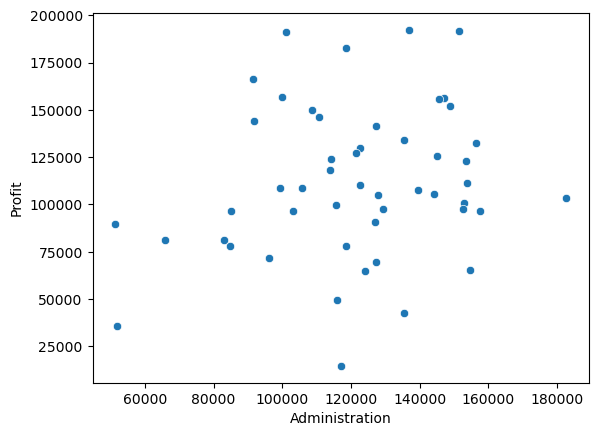

In [21]:
sns.scatterplot(x=df['Administration'],y=df['Profit'])
plt.show()

# Encoding

In [22]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

# One-Hot Encoding
 - One-Hot Encoding is a technique used to convert categorical data into numerical format so that machine learning algorithms can understand it

In [23]:
df=pd.get_dummies(data=df,columns=['State'],dtype=int)

In [24]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0
3,144372.41,118671.85,383199.62,182901.99,0,0,1
4,142107.34,91391.77,366168.42,166187.94,0,1,0


In [25]:
df=df[['R&D Spend','Administration','Marketing Spend','State_California','State_Florida','State_New York','Profit']]

# Correlation Analysis

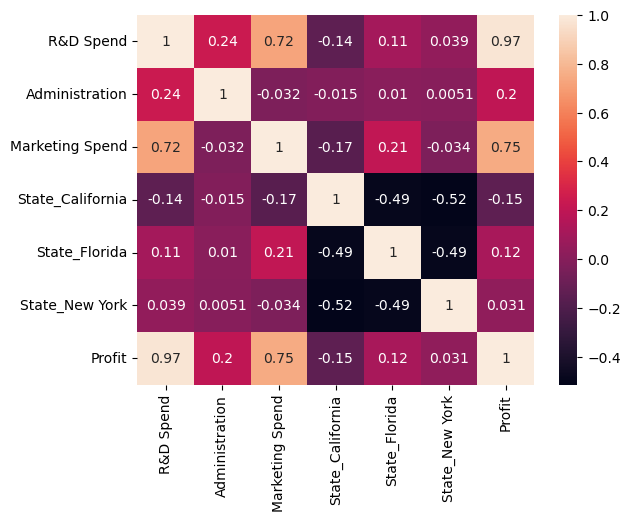

In [26]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [27]:
#Based on the correlation analysis, the Administration feature had a negligible correlation with Profit compared to R&D Spend and Marketing Spend. Therefore, the Administration column was excluded from the model to reduce unnecessary complexity and focus on the most influential predictors of startup profit
df.drop(columns=['Administration'],inplace=True)

In [28]:
df.head()

,R&D Spend,Marketing Spend,State_California,State_Florida,State_New York,Profit
0,165349.20,471784.10,0,0,1,192261.83
1,162597.70,443898.53,1,0,0,191792.06
2,153441.51,407934.54,0,1,0,191050.39
3,144372.41,383199.62,0,0,1,182901.99
4,142107.34,366168.42,0,1,0,166187.94


# Feature Selection

In [29]:
X=df.drop(columns=['Profit'])
y=df['Profit']

# Train-Test Split

In [30]:
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

In [31]:
x_train

,R&D Spend,Marketing Spend,State_California,State_Florida,State_New York
6,134615.46,127716.82,1,0,0
41,27892.92,164470.71,0,1,0
46,1315.46,297114.46,0,1,0
47,0.00,0.00,1,0,0
15,114523.61,261776.23,0,0,1
9,123334.88,304981.62,1,0,0
16,78013.11,264346.06,1,0,0
24,77044.01,140574.81,0,0,1
34,46426.07,210797.67,1,0,0
31,61136.38,88218.23,0,0,1


In [32]:
y_train

6     156122.51
41     77798.83
46     49490.75
47     42559.73
15    129917.04
9     149759.96
16    126992.93
24    108552.04
34     96712.80
31     97483.56
0     192261.83
44     65200.33
27    105008.31
33     96778.92
5     156991.12
29    101004.64
11    144259.40
36     90708.19
1     191792.06
21    111313.02
2     191050.39
43     69758.98
35     96479.51
23    108733.99
40     78239.91
10    146121.95
22    110352.25
18    124266.90
49     14681.40
20    118474.03
7     155752.60
42     71498.49
14    132602.65
28    103282.38
38     81229.06
Name: Profit, dtype: float64

In [33]:
x_test

,R&D Spend,Marketing Spend,State_California,State_Florida,State_New York
13,91992.39,252664.93,1,0,0
39,38558.51,174999.30,1,0,0
30,61994.48,91131.24,0,1,0
45,1000.23,1903.93,0,0,1
17,94657.16,282574.31,0,0,1
48,542.05,0.00,0,0,1
26,75328.87,134050.07,0,1,0
25,64664.71,137962.62,1,0,0
32,63408.86,46085.25,1,0,0
19,86419.70,0.00,0,0,1


In [34]:
y_test

13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
12    141585.52
4     166187.94
37     89949.14
8     152211.77
3     182901.99
Name: Profit, dtype: float64

# Model Building

In [35]:
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
print(f"Coefficient value: {lr.coef_}")
print(f"Slope value: {lr.intercept_}")

Coefficient value: [ 7.96742691e-01  2.97505939e-02 -4.04211702e+01  1.00365776e+02
 -5.99446056e+01]
Slope value: 46999.366153896626


# Prediction

In [37]:
y_pred=lr.predict(x_test)
y_pred

array([127770.14103889,  82886.48909989,  99204.58924072,  47792.99053796,
       130763.57544254,  47371.29592367, 111105.52769009, 102584.54989972,
        98850.55426385, 115793.68584176, 129317.86038055, 171216.44432683,
        87933.09778899, 152251.47371715, 173367.5002271 ])

# Evaluation

In [38]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y_test,y_pred)}')

Mean_squared_error: 58660718.61823915
Root_mean_squared_error: 7659.028568835551
Mean_absolute_error: 6057.279033889487
R2_score: 0.958307976234724


# Score


In [39]:
print(f'Training Accurary: {lr.score(x_train,y_train)}')
print(f'Testing Accuray: {lr.score(x_test,y_test)}')

Training Accurary: 0.9475563566664903
Testing Accuray: 0.958307976234724


# Conclusion
 - The Multiple Linear Regression model performed very well in predicting startup profits.
 - The R² Score of 0.9583 indicates that approximately 95.83% of the variation in profit is explained by the independent variables (R&D Spend, Administration, Marketing Spend, and State).
 - The Mean Absolute Error (MAE) of 6057.28 shows that the model's predictions differ from the actual profit values by about $6,057 on average.
 - The Root Mean Squared Error (RMSE) of 7659.03 indicates that the typical prediction error is around $7,659, which is relatively low compared to the overall profit range in the dataset.
 - The low error values and high R² score demonstrate that the model fits the data effectively and captures the relationship between startup expenditures and profit.